In [98]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
from scipy import stats
import emcee
import time
import math
import corner

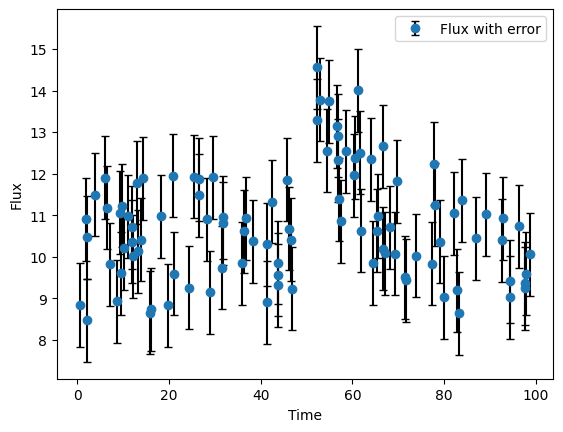

In [57]:
data=np.load("Transient.npy")

times=data[:,0]
flux=data[:,1]
err=data[:,2]

plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [ ]:
#Try with Log to avoid RuntimeWarning

#The model given the parameters and time

def model(params):
    A,b,t0,alpha=params
    array=np.full_like(times,1)
    array[times<=t0]=b
    array[times>t0]=b+A*np.exp(-alpha*(times[times>t0]-t0))
    return array
 
#I'm assuming gaussian noise, so I expect that the (flux - model) = noise (gaussian distribution) (TCL)
#I can ingore normalization because i'm not interested in the evidnce in this case 
def LogLikelihood(params):
   return  -0.5 * np.sum(((flux - model(params)) / err) ** 2)


In [59]:
#Prior and Posterior definition
#I take care of the normalizations to understand better but it is not necessary 

def prior_t0(t0):
    if t0<0 or t0>100:
        return 0
    else:
        return 1/100

def prior_A(a):
    if a<0 or a>50:
        return 0
    else:
        return 1/50
    
def prior_b(b):
    if b<0 or b>50:
        return 0
    else:
        return 1/50

def prior_alpha(alpha):
    if alpha<math.exp(-5) or alpha>math.exp(5):
        return 0
    else:
        return 1/10/alpha
    
def prior(params):
    a,b,t0,alpha=params
    return prior_t0(t0)*prior_A(a)*prior_b(b)*prior_alpha(alpha)

def LogPosterior (params):
    if prior(params)==0:
        return -np.inf
    lp = np.log(prior(params))
    return LogLikelihood(params)+lp


In [ ]:
ndim = 4  
nwalkers = 10  
nsteps = 100000  #it takes about 4minutes 

t0_quick=50
A_quick=5
b_quick=10
alpha_quick=0.1 

Param_guess= np.array([A_quick,b_quick,t0_quick,alpha_quick])

# initialize theta 
np.random.seed(0)
starting_guesses = Param_guess+1e-3*np.random.random((nwalkers, ndim))          #starting point for each walker for each parameter

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)

elapsed=time.time()
sampler.run_mcmc(starting_guesses, nsteps)                  #actually run the MCMC
print(time.time()-elapsed)



168.03457188606262


In [77]:
print(sampler.chain.shape)
emcee_trace  = sampler.chain[:, 10000:, :].reshape(-1, ndim)
print(emcee_trace.shape)


(10, 100000, 4)
(900000, 4)


It takes a while....

Plot showing the chain

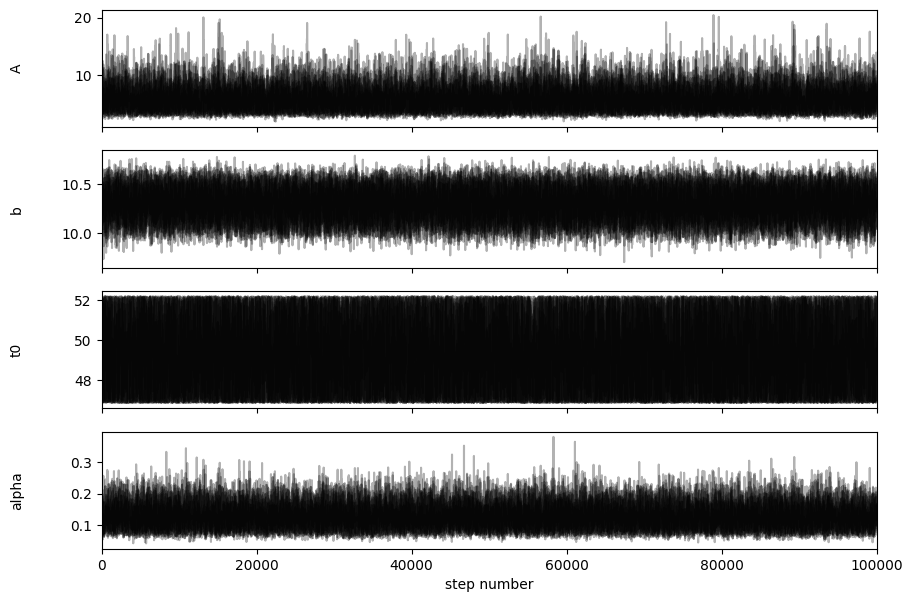

In [69]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

#### Let's focus on the autocorrelation length

In [99]:
tau = sampler.get_autocorr_time()           #autocorrelation time for each parameter
print(tau)

[95.4815433  68.20974675 93.67516632 76.16308388]


I'm going to thin the chain keeping point each MAX autocorrelation length, I discard as burn in 3 times the autocorrelation length 

In [100]:
samples2 = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)))
print(samples2.shape) 
#without flattening, the shape is (nburned_steps, nwalkers, ndim)

(1049, 10, 4)


In [101]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)
# I think we have enought points 

(10490, 4)


### 4D corner plot 

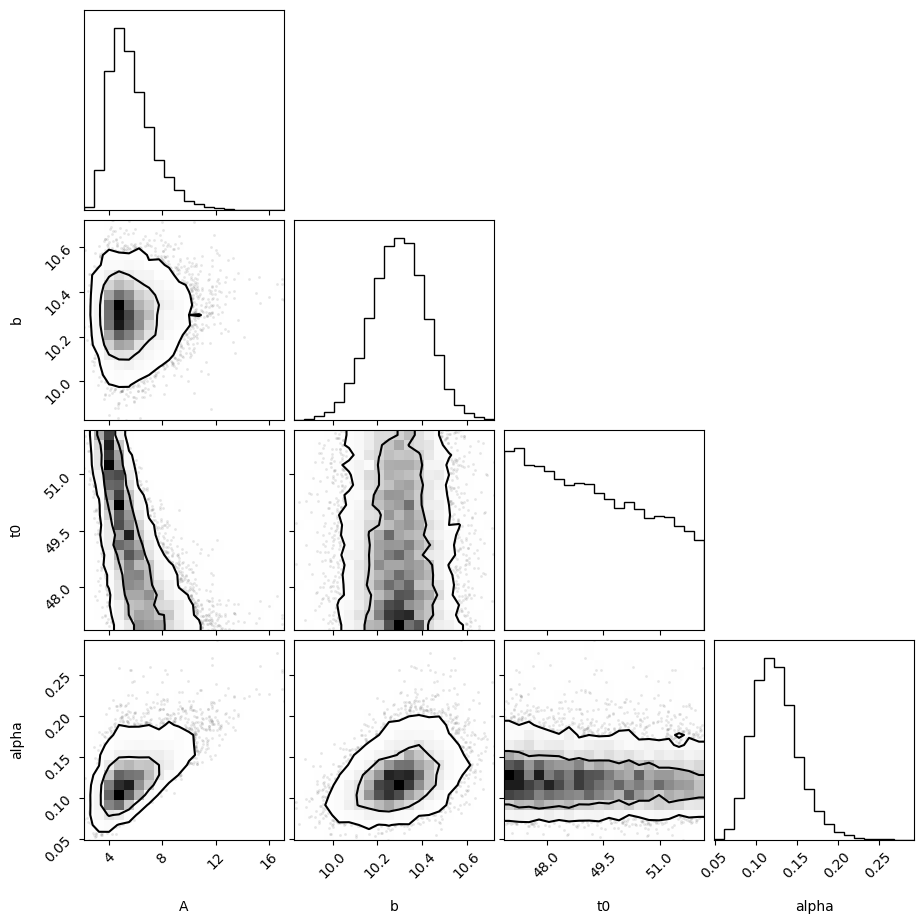

In [ ]:
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95]);

Let's try to discard too many points:

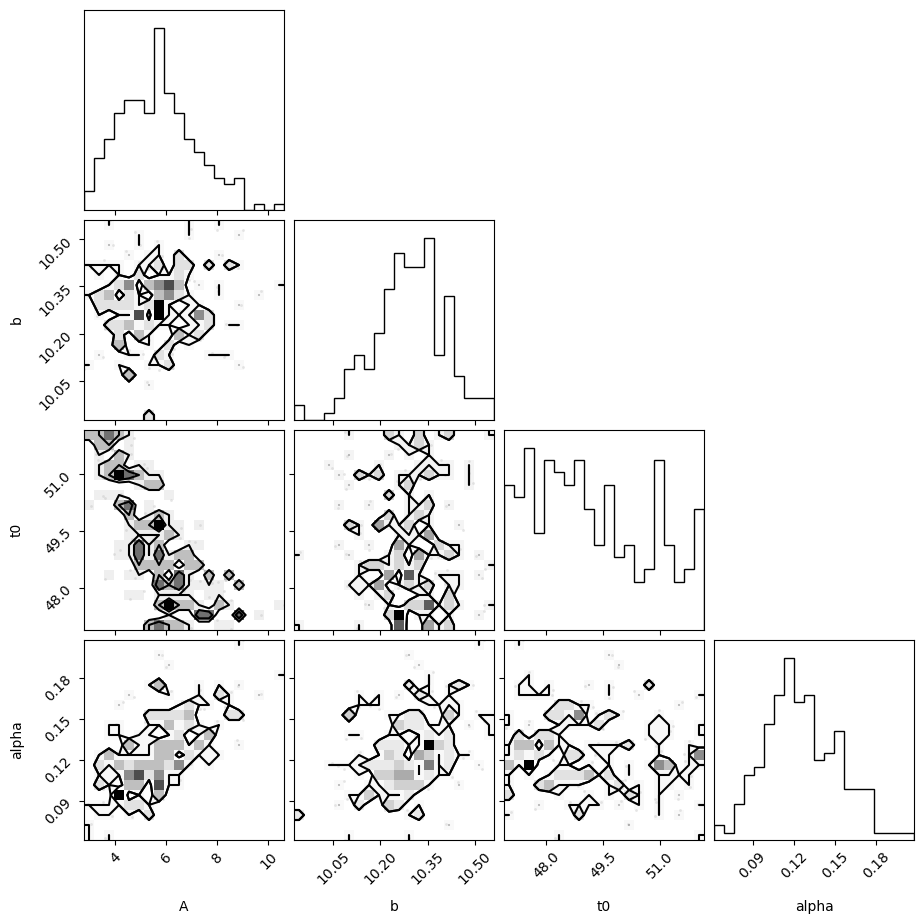

In [ ]:
low_Ntry = sampler.get_chain(discard=3*int(max(tau)), thin=5000, flat=True)
fig = corner.corner(low_Ntry, labels=labels, levels=[0.68,0.95]);
#of course with few points we don't sample the posterior well 

#### Now I choose 100 random samples from the burned and thinned chain. They show the posterior spread of the model. 

I plot also the MAP, the most probable model



In [97]:
samp100 = flat_samples[np.random.choice(len(flat_samples),size=100)] #100 random indeces 

log_prob = sampler.get_log_prob(discard=3*int(max(tau)), thin=int(max(tau)), flat=True) #the log probabilities evaluated at the MCMC samples
log_prob.shape #each value correspond to a set of parameters 
i_map = np.argmax(log_prob) 

flat_samples[i_map]


array([ 3.7795008 , 10.27531021, 52.11512135,  0.1131036 ])

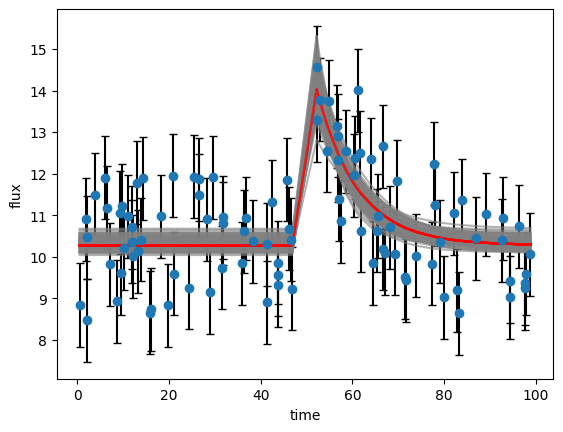

In [102]:
plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
for i in range(len(samp100)):
    y = model(samp100[i])
    z= model(flat_samples[i_map])
    plt.plot(times,y,alpha=0.6, c='gray')
    plt.plot(times,z,alpha=0.6, c='red')
plt.xlabel("time")
plt.ylabel("flux");

Statistics of the data

In [ ]:
for i,l in enumerate(labels):
    low,med, up = np.percentile(flat_samples[:,i],[5,50,95]) 
    print(l+"   "+str(med)+" + "+str(up-med)+" -"+str(med-low))

A   5.368126851994935 +3.473407844456599 -1.7625483712868943
b   10.296560385843057 +0.19652800399822823 -0.2055679904558101
t0   49.10618130555833 +2.692742853284088 -2.0424650936020967
alpha   0.12258515867061281 +0.05287709530392509 -0.03740693691995821
